In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import json

evo_trace_file = '/home/shenm19/prj/treesearch/output/func_min/run_2/evolution_trace.jsonl'


def read_jsonl_file(filepath):
    data = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            try:
                json_object = json.loads(line.strip()) # .strip() removes leading/trailing whitespace, including newline characters
                data.append(json_object)
            except json.JSONDecodeError as e:
                print(f"Error decoding JSON on line: {line.strip()}. Error: {e}")
    return data

trace = read_jsonl_file(evo_trace_file)
trace

[{'iteration': 1,
  'timestamp': 1761679769.3804646,
  'parent_id': 'e54e5380-b16e-4b9b-a94b-3dbaa5fc6b5f',
  'child_id': '5278015d-89b8-4251-a149-bf89eec8d0c7',
  'parent_metrics': {'runs_successfully': 1.0,
   'value_score': 0.9417587299889709,
   'distance_score': 0.7565915427363771,
   'combined_score': 1.2147685971231066},
  'child_metrics': {'runs_successfully': 1.0,
   'value_score': 0.9682197825151668,
   'distance_score': 0.8608994592307212,
   'combined_score': 1.295408314481944},
  'prompt': {'system': 'You are an expert programmer specializing in optimization algorithms. Your task is to improve a function minimization algorithm to find the global minimum of a complex function with many local minima. The function is f(x, y) = sin(x) * cos(y) + sin(x*y) + (x^2 + y^2)/20. Focus on improving the search_algorithm function to reliably find the global minimum, escaping local minima that might trap simple algorithms.',
   'user': '# Current Program Information\n- Fitness: 1.2148\n-

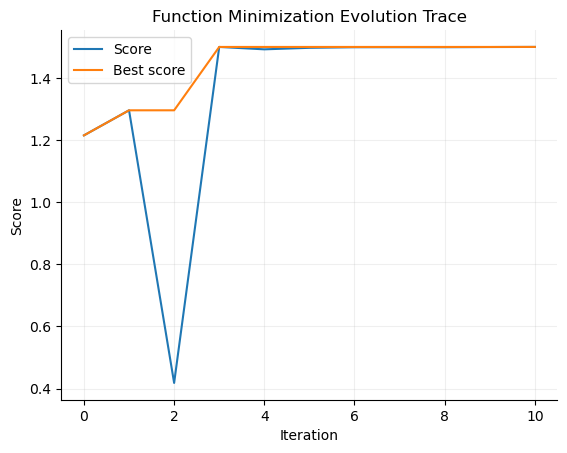

In [23]:
scores = [trace[0]['parent_metrics']['combined_score']] + [trace[i]['child_metrics']['combined_score'] for i in range(len(trace))]
iterations = [0] + [trace[i]['iteration'] for i in range(len(trace))]

best_scores_seen = [max(scores[:i+1]) for i in range(len(scores))]

plt.plot(iterations, scores, label = 'Score')
plt.plot(iterations, best_scores_seen, label = 'Best score')
plt.xlabel('Iteration')
plt.ylabel('Score')
plt.title('Function Minimization Evolution Trace')
plt.legend()
plt.grid(alpha = 0.2)
sns.despine()

/tmp/ipykernel_1335331/1034692711.py:89: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = mpl.cm.get_cmap(cmap_name)


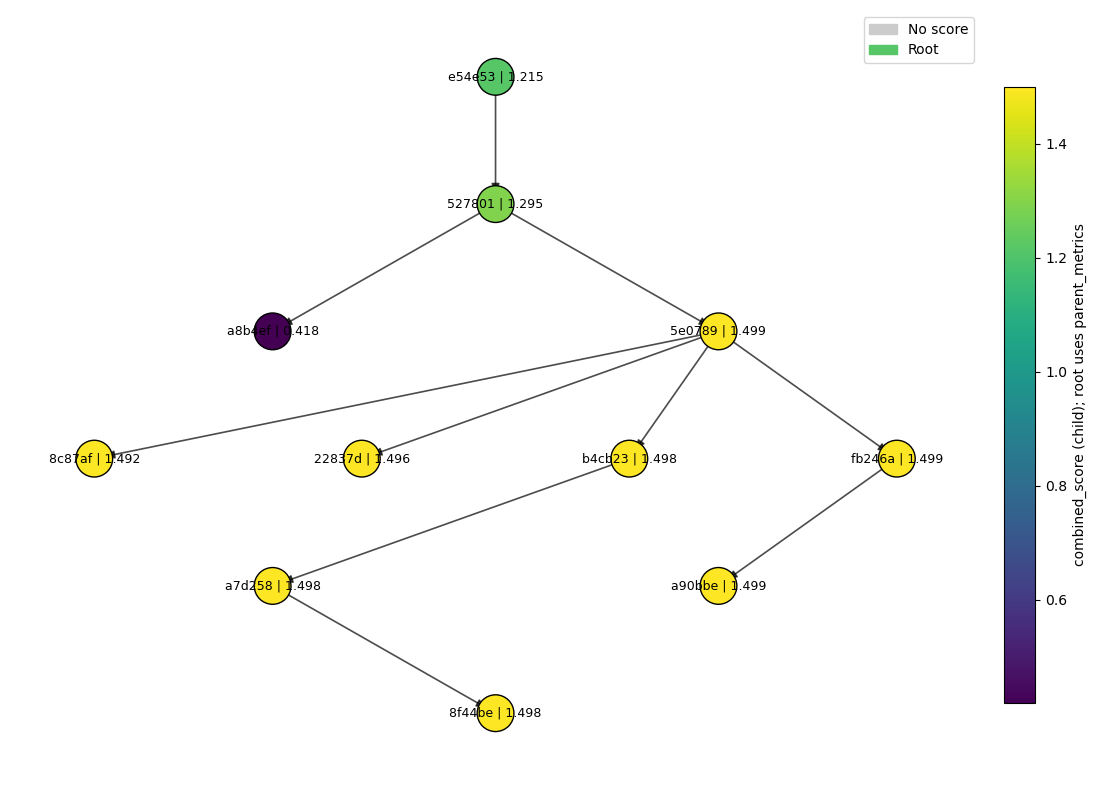

In [25]:
import math
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

def plot_parent_child_dag(records, *,
                          figsize=(12, 8),
                          node_size=700,
                          cmap_name="viridis",
                          seed=42,
                          label_precision=3):
    """
    records: list[dict].
      - Each record contributes an edge parent_id -> child_id.
      - Nodes are colored by child_metrics['combined_score'] of the *child*.
      - The root node is records[0]['parent_id'] and is colored/labeled by
        records[0]['parent_metrics']['combined_score'].
      - Node labels show: first 6 chars of node id + its combined_score (or NA).
    """

    # 0) Identify root and its score (per your rule)
    root_id = records[0]["parent_id"] if records else None
    root_score = None
    if records:
        pm = records[0].get("parent_metrics", {})
        if pm is not None:
            root_score = pm.get("combined_score", None)

    # 1) Build the directed graph
    G = nx.DiGraph()
    for r in records:
        p = r["parent_id"]
        c = r["child_id"]
        G.add_edge(p, c)

    # Ensure the root exists even if it has no edges
    if root_id is not None:
        G.add_node(root_id)

    # 2) Gather the child combined_score per node (latest by timestamp)
    score_by_node = {}
    ts_by_node = {}
    for r in records:
        c = r["child_id"]
        ts = r.get("timestamp", float("-inf"))
        s = r.get("child_metrics", {}).get("combined_score", None)
        if s is None:
            continue
        if c not in ts_by_node or ts > ts_by_node[c]:
            ts_by_node[c] = ts
            score_by_node[c] = float(s)

    # Root override: color/label the root by parent_metrics['combined_score']
    if root_id is not None and root_score is not None:
        score_by_node[root_id] = float(root_score)

    # 3) Compute a layout (layered if DAG; spring layout otherwise)
    try:
        is_dag = nx.is_directed_acyclic_graph(G)
    except Exception:
        is_dag = False

    if is_dag and len(G) > 0:
        gens = list(nx.topological_generations(G))
        pos = {}
        for yi, gen in enumerate(gens):
            xs = np.linspace(0, 1, len(gen) + 2)[1:-1]
            for x, n in zip(xs, gen):
                pos[n] = (x, -yi)
    else:
        k = 1 / math.sqrt(max(len(G), 1))
        pos = nx.spring_layout(G, k=k, seed=seed)

    # 4) Colors for each node
    nodes = list(G.nodes())
    scores = np.array([score_by_node.get(n, np.nan) for n in nodes], dtype=float)

    finite = scores[np.isfinite(scores)]
    if finite.size == 0:
        vmin, vmax = 0.0, 1.0
    else:
        vmin, vmax = float(np.min(finite)), float(np.max(finite))
        if vmin == vmax:
            vmin -= 1e-6
            vmax += 1e-6

    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax, clip=True)
    cmap = mpl.cm.get_cmap(cmap_name)

    node_colors = [cmap(norm(s)) if np.isfinite(s) else (0.8, 0.8, 0.8, 1.0) for s in scores]

    # 5) Build labels: "<first6>\n<score or NA>"
    def fmt_score(x):
        return f"{x:.{label_precision}f}" if (x is not None and np.isfinite(x)) else "NA"

    labels = {
        n: f"{str(n)[:6]} | {fmt_score(score_by_node.get(n, np.nan))}"
        for n in nodes
    }

    # 6) Draw
    fig, ax = plt.subplots(figsize=figsize)
    nx.draw_networkx_edges(
        G, pos,
        arrows=True, arrowstyle='-|>', arrowsize=12,
        width=1.2, alpha=0.7, ax=ax
    )
    nx.draw_networkx_nodes(
        G, pos,
        node_color=node_colors,
        node_size=node_size,
        edgecolors="black", linewidths=1, ax=ax
    )
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=9, ax=ax)

    # 7) Colorbar for the score scale
    sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, shrink=0.8, pad=0.02, ax=ax)
    cbar.set_label("combined_score (child); root uses parent_metrics")

    # 8) Legend for missing scores
    import matplotlib.patches as mpatches
    handles = [mpatches.Patch(color=(0.8, 0.8, 0.8, 1.0), label="No score")]
    if root_id is not None and root_score is not None:
        handles.append(mpatches.Patch(color=cmap(norm(score_by_node[root_id])), label="Root"))
    ax.legend(handles=handles, loc="upper right", frameon=True)

    ax.set_axis_off()
    fig.tight_layout()
    plt.show()

plot_parent_child_dag(trace)
